## Frequency & Distribution

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# The code to mimic the roll dice game for 50 times

die = pd.DataFrame([1,2,3,4,5,6])
trial = 50
results = [die.sample(2, replace=True).sum().loc[0] for i in range(trial)]

In [5]:
# The code for summarising the results of sum of faces by frequency

freq = pd.DataFrame(results)[0].value_counts()
sort_freq = freq.sort_index()
print(sort_freq)

0
2      2
3      2
4      4
5      3
6      7
7      7
8     11
9      4
10     4
11     4
12     2
Name: count, dtype: int64


<Axes: xlabel='0'>

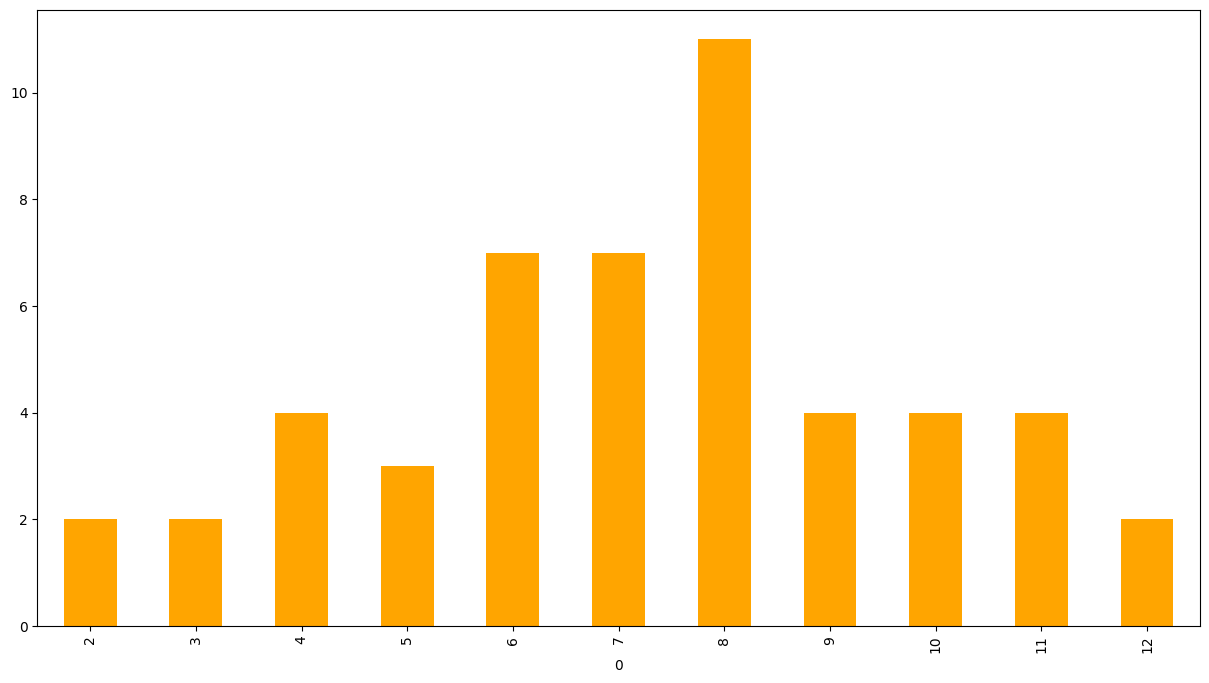

In [6]:
# plot the bar chart based on the result

sort_freq.plot(kind='bar', color='orange', figsize=(15,8))

#### Relative Frequency

<Axes: xlabel='0'>

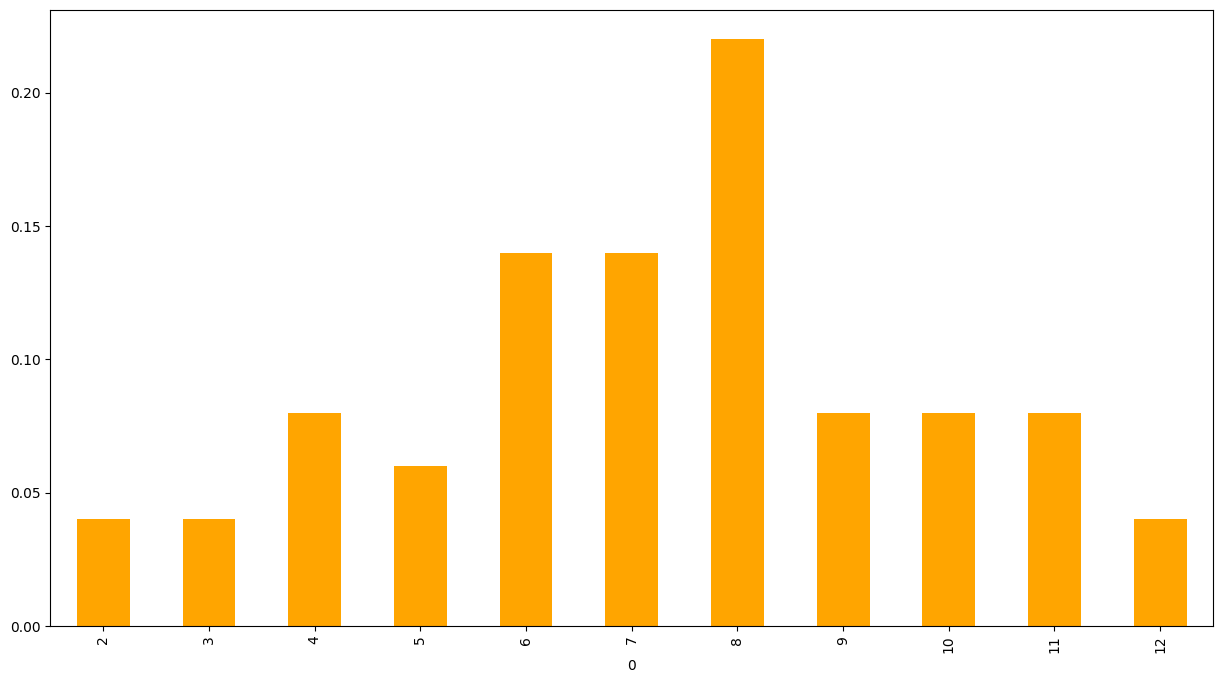

In [7]:
# Using relative frequency, we can rescale the frequency so that we can compare results from different number of trials
relative_freq = sort_freq/trial
relative_freq.plot(kind='bar', color='orange',figsize=(15,8))

<Axes: xlabel='0'>

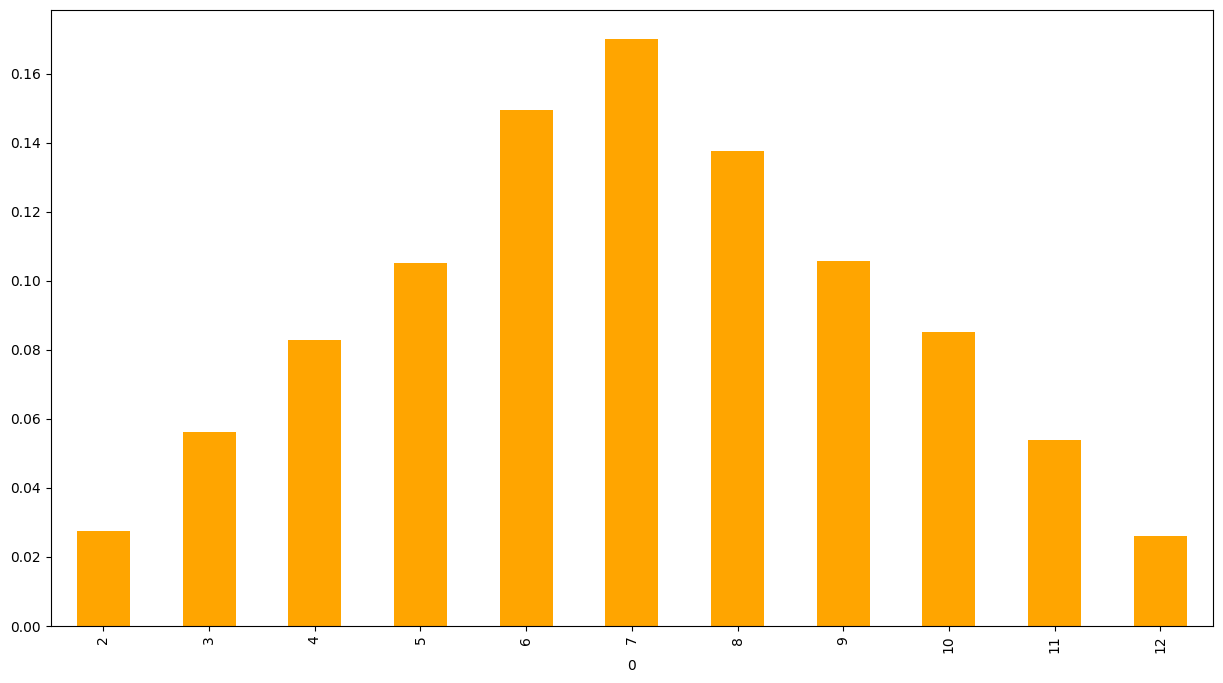

In [8]:
# let's try to increase the number of trials to 10k, and see what will happen
trial = 10000
results = [die.sample(2, replace=True).sum().loc[0] for i in range(trial)]
freq = pd.DataFrame(results)[0].value_counts()
sort_freq = freq.sort_index()
relative_freq = sort_freq/trial
relative_freq.plot(kind='bar', color='orange', figsize=(15,8))

##### We can see that with more trials, the result looks more and more stable, and this is very close to a probability distribution.

<Axes: xlabel='0'>

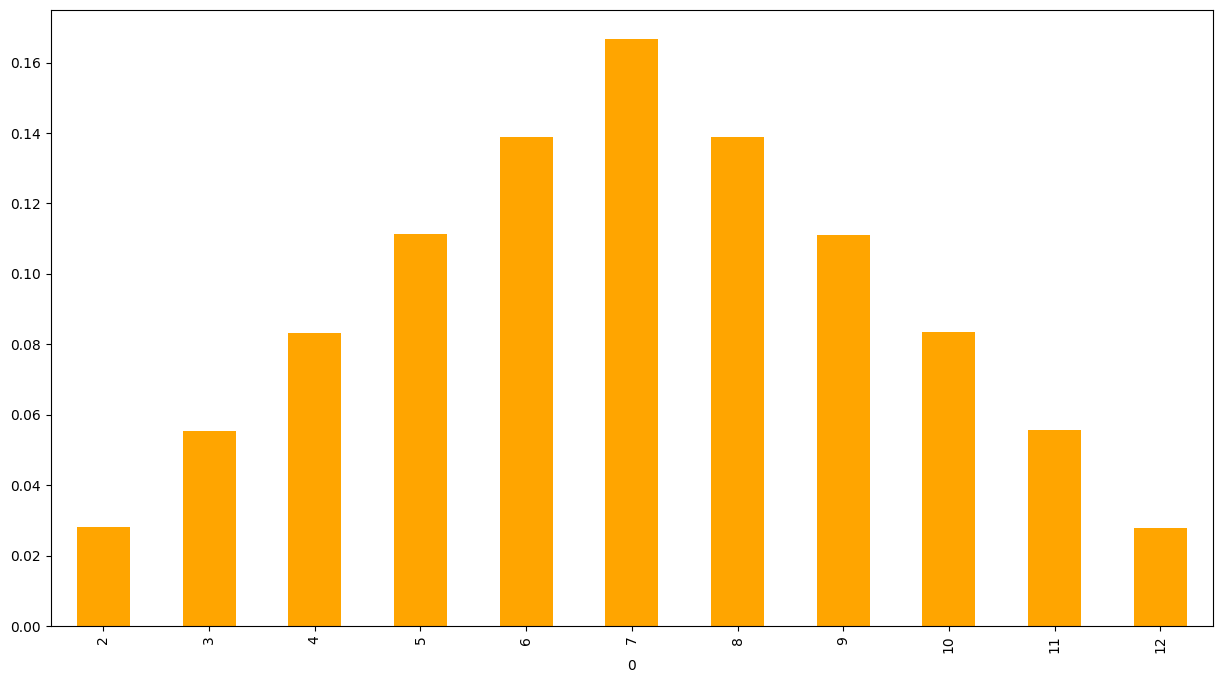

In [9]:
# let's try to increase the number of trials to 1 mil, and see what will happen
trial = 1000000
results = [die.sample(2, replace=True).sum().loc[0] for i in range(trial)]
freq = pd.DataFrame(results)[0].value_counts()
sort_freq = freq.sort_index()
relative_freq = sort_freq/trial
relative_freq.plot(kind='bar', color='orange', figsize=(15,8))

### Expectation and Variance of  distribution

In [10]:
# assume that we have a fair dice, which means all faces will be shown with equal probability
# then we can say we know the "distribution" of the random variable - sum_of_dice

x_distri = pd.DataFrame(index=[2,3,4,5,6,7,8,9,10,11,12])
x_distri['Prob'] = [1,2,3,4,5,6,5,4,3,2,1]
x_distri['Prob'] = x_distri['Prob']/36
x_distri

,Prob
2,0.027778
3,0.055556
4,0.083333
5,0.111111
6,0.138889
7,0.166667
8,0.138889
9,0.111111
10,0.083333
11,0.055556


In [11]:
mean = pd.Series(x_distri.index * x_distri['Prob']).sum()
var = pd.Series(((x_distri.index - mean)**2)*x_distri['Prob']).sum()

In [12]:
# Output the mean and varianve of the distribution. Mean and variance can be used to describe a distribution 
print(f'Mean: {mean}, Variance: {var}')

Mean: 6.999999999999998, Variance: 5.833333333333333


### Empirical mean and variance

In [13]:
# if we calculate mean and variance of outcomes (with high number of trials, ex. - 50000)
trial = 50000
results = [die.sample(2, replace=True).sum().loc[0] for i in range(trial)]

In [14]:
# print the mean and variance of 50k trials
results = pd.Series(results)
print(f'Mean: {results.mean()}, Variance: {results.var()}')

Mean: 6.99878, Variance: 5.807774667093343
